In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

import re
import pandas as pd

import lsstypes 
from clustering_statistics.tools import get_stats_fn
from tools import read_data, rebin_data

os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

plt.style.use('ec_style.mplstyle')   

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = Path('/Users/edmond/Work/data/desi-clustering/') 

stats_dir = root / Path('dr2/summary_statistics/local_png/base')
project = 'holi-v4-altmtl/'

data_dir = root / Path('dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/')

[MacBook-Pro-de-Edmond-1003.local:48808] shmem: mmap: an error occurred while determining whether or not /var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T//ompi.MacBook-Pro-de-Edmond-1003.501/jf.0/1517486080/sm_segment.MacBook-Pro-de-Edmond-1003.501.5a730000.0 could be created.


In [2]:
def _get_available_mock_ids(base_dir):
    # Expected mock range
    mock_min, mock_max = 0, 999

    # 1) Inventory of available mock directories
    mock_ids_present = sorted(int(m.group(1)) for p in base_dir.iterdir() if p.is_dir() and (m := re.match(r'^mock(\d+)$', p.name)))
    if not mock_ids_present: raise RuntimeError(f'No mockN directory found in {base_dir}')
    mock_ids_expected = list(range(mock_min, mock_max + 1))
    mock_ids_missing = sorted(set(mock_ids_expected) - set(mock_ids_present))
    print(f'Discovered {len(mock_ids_present)=} mock directories over 1000 expected (0-{mock_max})')

    return mock_ids_expected, mock_ids_present, mock_ids_missing


def _discover_available_by_stats(base_dir, stats_kind='mesh2_spectrum_poles'):
    """Discover available tracers, redshift ranges, regions, and weights by scanning existing files."""
    escaped_kind = re.escape(stats_kind)
    pattern = re.compile(
        rf'^{escaped_kind}_(?P<tracer>.+?)_z(?P<zmin>\d+(?:\.\d+)?)-(?P<zmax>\d+(?:\.\d+)?)_(?P<region>[^_]+)_weight-(?P<weight>.+)\.h5$'
    )

    tracers_available = set()
    zranges_by_tracer = {}
    regions_by_tracer = {}
    weights_by_tracer = {}

    for mock_dir in base_dir.glob('mock*'):
        if not mock_dir.is_dir():
            continue
        for fn in mock_dir.glob(f'{stats_kind}_*.h5'):
            match = pattern.match(fn.name)
            if not match:
                continue

            tracer = match.group('tracer')

            raw_weight = match.group('weight')
            weight = raw_weight.removesuffix('_auw').removesuffix('_thetacut')
            zrange = (float(match.group('zmin')), float(match.group('zmax')))
            region = match.group('region')

            tracers_available.add(tracer)
            zranges_by_tracer.setdefault(tracer, set()).add(zrange)
            regions_by_tracer.setdefault(tracer, set()).add(region)
            weights_by_tracer.setdefault(tracer, set()).add(weight)

    tracers_available = sorted(tracers_available)
    zranges_by_tracer = {tracer: sorted(zranges_by_tracer.get(tracer, set())) for tracer in tracers_available}
    regions_by_tracer = {tracer: sorted(regions_by_tracer.get(tracer, set())) for tracer in tracers_available}
    weights_by_tracer = {tracer: sorted(weights_by_tracer.get(tracer, set())) for tracer in tracers_available}

    return tracers_available, zranges_by_tracer, regions_by_tracer, weights_by_tracer


def get_inventory(stats_dir, project, stats_kind='mesh2_spectrum_poles'):
    """ Get an inventory of expected files based on discovered tracers, redshift ranges, regions, and weights."""
    base_dir = stats_dir / project
    print(f'Directory: {base_dir} -- scanning for stats files of kind "{stats_kind}" to discover available tracers, redshift ranges, regions, and weights...')

    # 1) Inventory of available mock directories
    mock_ids_expected, mock_ids_present, mock_ids_missing = _get_available_mock_ids(base_dir)

    tracers_available, zranges_by_tracer, regions_by_tracer, weights_by_tracer = _discover_available_by_stats(base_dir=base_dir, stats_kind=stats_kind)

    # 3) Inventory of expected files using get_stats_fn with discovered tracer-specific z-ranges, regions and weights
    rows = []
    for tracer in tracers_available:
        tracer_zranges = zranges_by_tracer.get(tracer, [])
        tracer_regions = regions_by_tracer.get(tracer, [])
        tracer_weights = weights_by_tracer.get(tracer, [])
        if not tracer_zranges or not tracer_regions or not tracer_weights:
            continue
        for imock in mock_ids_expected:
            for zrange in tracer_zranges:
                for region in tracer_regions:
                    for weight in tracer_weights:
                        fn = get_stats_fn(stats_dir=stats_dir, project=project, kind=stats_kind, tracer=tracer, region=region, zrange=zrange, weight=weight,    
                                        imock=imock, auw=False, cut=False)
                        rows.append({'tracer': tracer, 'weight': weight, 'imock': imock, 'zrange': '-'.join(str(x) for x in zrange), 
                                    'region': region, 'exists': fn.exists(), 'path': str(fn)})
        
    return pd.DataFrame(rows)

In [4]:
inventory = get_inventory(stats_dir=stats_dir, project=project, stats_kind='mesh2_spectrum_poles')
available = inventory[inventory['exists']]
summary = (inventory.groupby(['tracer', 'weight', 'zrange', 'region'], as_index=False).agg(available=('exists', 'sum')))

tracers_available = np.unique(summary['tracer'])
zranges_by_tracer = dict(np.unique(summary[['tracer', 'zrange']].apply(tuple, axis=1)))

for tracer in tracers_available:
    tracer_summary = summary[summary['tracer'] == tracer]
    display(tracer_summary.sort_values(['weight', 'zrange', 'region']))

#display(summary.sort_values(['tracer', 'weight', 'zrange', 'region']))

Directory: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/holi-v4-altmtl -- scanning for stats files of kind "mesh2_spectrum_poles" to discover available tracers, redshift ranges, regions, and weights...
Discovered len(mock_ids_present)=985 mock directories over 1000 expected (0-999)


,tracer,weight,zrange,region,available
0,ELGnotqso,default-fkp-oqe,0.8-1.6,NGC,438
1,ELGnotqso,default-fkp-oqe,0.8-1.6,SGC,530


,tracer,weight,zrange,region,available
2,LRG,default-FKP,0.4-1.1,NGC,765
3,LRG,default-FKP,0.4-1.1,SGC,783
4,LRG,default-fkp-oqe,0.4-1.1,NGC,704
5,LRG,default-fkp-oqe,0.4-1.1,SGC,770


,tracer,weight,zrange,region,available
6,QSO,default-fkp-oqe,0.8-3.5,GCcomb,985
7,QSO,default-fkp-oqe,0.8-3.5,NGC,985
8,QSO,default-fkp-oqe,0.8-3.5,SGC,985


In [ ]:
for tracer in tracers_available:
    to_check = [i for i in range(1000)]
    list_available = list(available[(available['tracer'] == 'LRG') & (available['region'] == 'GCcomb') & (available['weight'] == 'default-fkp-oqe')]['imock'])
    not_available = sorted(set(to_check) - set(list_available))
    print(tracer, not_available)

#print('From Alberto: These mocks are not available yet with altmtl due to sysnet error -> should be ready soon.')

ELGnotqso []
ELGnotqsoxQSO []
LRG []
LRGxELGnotqso []
LRGxQSO []
QSO []
From Alberto: These mocks are not available yet with altmtl due to sysnet error -> should be ready soon.


## Mocks vs. Data:

Reading the window without integral constraint contribution...


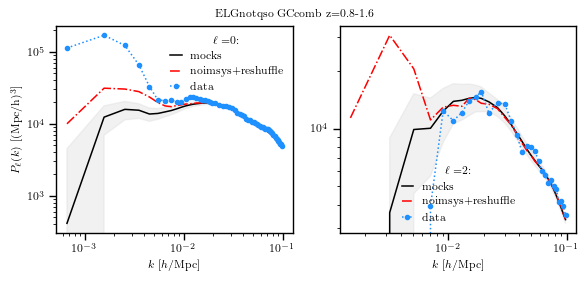

Reading the window without integral constraint contribution...


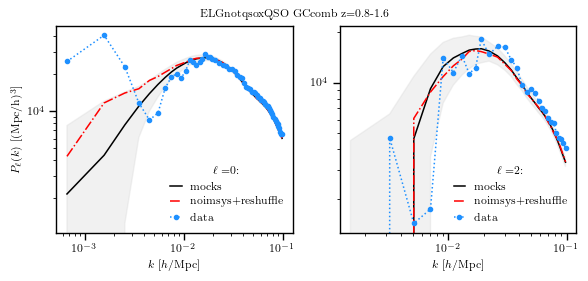

Reading the window without integral constraint contribution...


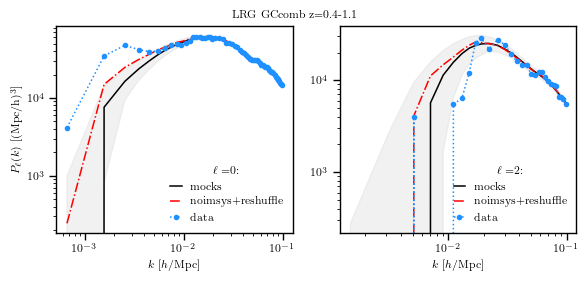

Reading the window without integral constraint contribution...


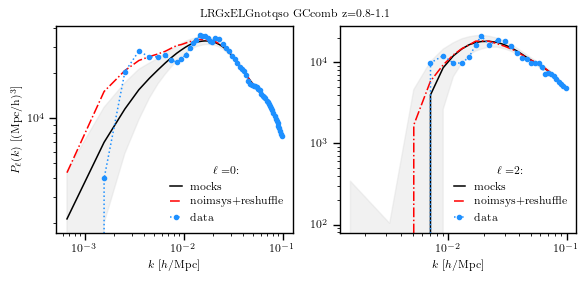

Reading the window without integral constraint contribution...


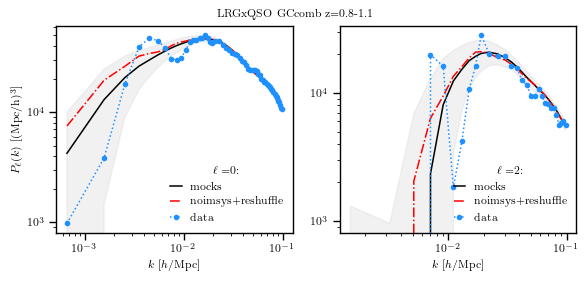

Reading the window without integral constraint contribution...


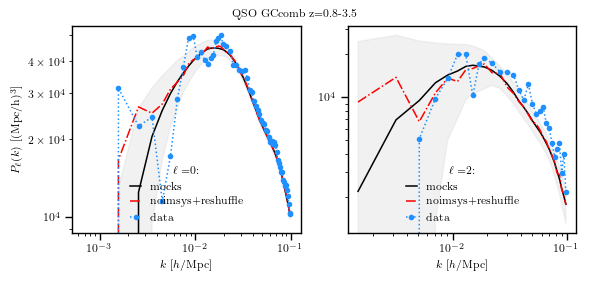

Reading the window without integral constraint contribution...
Reading the window without integral constraint contribution...
Reading the window without integral constraint contribution...
Reading the window without integral constraint contribution...
Reading the window without integral constraint contribution...
Reading the window without integral constraint contribution...


In [5]:
for logscale in [True, False]:

    if logscale:
        pdf_path = Path('fig/check_mocks_all_figures.pdf')
    else:
        pdf_path = Path('fig/check_mocks_all_figures_linear.pdf')

    with PdfPages(pdf_path) as pdf:
        for tracer in tracers_available:
            region = 'GCcomb'
            zrange = zranges_by_tracer.get(tracer, [])

            try:
                pk_data, _, _ = read_data(stats_dir=data_dir, tracer=tracer, zrange=zrange.split('-'), weight_type='default-fkp-oqe', region=region)
                pk_data, _, _ = rebin_data(pk_data, None, None, kmin=1e-4, kmax=0.1)

                sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe')
                fns = list(available[sel]['path'])

                sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-noimsys-fkp-oqe')
                fns_noimsys = list(available[sel]['path'])

                sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe_reshuffle')
                fns_reshuffle = list(available[sel]['path'])

                sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-noimsys-fkp-oqe_reshuffle')
                fns_noimsys_reshuffle = list(available[sel]['path'])

                pks = [rebin_data(lsstypes.read(fn), None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns]
                mean = lsstypes.mean(pks)

                fig = plt.figure(figsize=(6, 3))
                for ill, ell in enumerate([0, 2]):
                    ax = fig.add_subplot(1, 2, ill + 1)
                    k = mean.get(ell).k
                    mm = mean.get(ell).value()

                    if len(fns) > 1:
                        std = np.std([pk.get(ell).value() for pk in pks], axis=0)
                        ax.fill_between(k, mm - std, mm + std, color='lightgray', alpha=0.3)
                    else:
                        std = np.zeros_like(mm)
                    ax.plot(k, mm, c='black', label=f'mocks')

                    # if len(fns_noimsys) > 0:
                    #     pk_noimsys = lsstypes.mean([rebin_data(lsstypes.read(fn), None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns_noimsys])
                    #     ax.plot(k, pk_noimsys.get(ell).value(), c='dimgray', ls='--', label='noimsys')

                    # if len(fns_reshuffle) > 0:
                    #     pk_reshuffle = lsstypes.mean([rebin_data(lsstypes.read(fn), None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns_reshuffle])
                    #     ax.plot(k, pk_reshuffle.get(ell).value(), c='gray', ls=':', label='reshuffle')

                    if len(fns_noimsys_reshuffle) > 0:
                        pk_noimsys_reshuffle = lsstypes.mean([rebin_data(lsstypes.read(fn), None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns_noimsys_reshuffle])
                        ax.plot(k, pk_noimsys_reshuffle.get(ell).value(), c='red', ls='-.', label='noimsys+reshuffle')

                    ax.plot(k, pk_data.get(ell).value(), marker='o', ls=':', c='dodgerblue', markersize=3, label='data')
                    # ax.errorbar(k, pk_data.get(ell).value(), yerr=std, fmt='o', c='black', markersize=2, label='data')


                    ax.set_xlabel(r'$k$ [$h/$Mpc]')
                    ax.set_xscale('log')
                    if logscale: ax.set_yscale('log')
                    if ill == 0:
                        ax.set_ylabel(r'$P_{\ell}(k)$ [$(\rm{Mpc}/h)^3$]')
                    ax.legend(title=rf'$\ell=${ell}:')

                fig.suptitle(f'{tracer} {region} z={zrange}', fontsize=8, y=0.92)
                fig.tight_layout()
                pdf.savefig(fig)
                if logscale:
                    plt.show(fig)
                else:
                    plt.close(fig) 

            except Exception as e:
                print(f"Erreur pour {tracer}: {e}")

    # print(f"Figure sauvegardée: {pdf_path.resolve()}")

## Analytical covariance vs Mocks covariance:

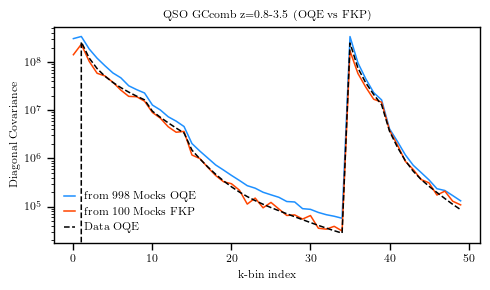

In [35]:
## Specific test for QSO: (OQE vs FKP):

tracer = 'QSO'
region = 'GCcomb'
zrange= '0.8-3.5'

sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe')
fns = list(available[sel]['path'])
pks = [rebin_data(lsstypes.read(fn), None, None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns]
cov_oqe = lsstypes.cov(pks)

sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp')
fns = list(available[sel]['path'])
pks = [rebin_data(lsstypes.read(fn), None, None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns]
cov_fkp = lsstypes.cov(pks)

pk_data, _, cov_data, mm = read_data(data_dir=data_dir, tracer=tracer, zrange=zrange.split('-'), weight_type='default-fkp-oqe', region=region)
pk_data, _, cov_data, _ = rebin_data(pk_data, None, cov_data, mm, tracer=tracer, kmin=1e-4, kmax=0.1)


plt.figure(figsize=(5, 3))
plt.plot(np.diag(cov_oqe.value()), label=f'from 998 Mocks OQE')
plt.plot(np.diag(cov_fkp.value()), label=f'from 100 Mocks FKP')
plt.plot(np.diag(cov_data.value()), ls='--', c='k', label=f'Data OQE')
plt.title(f'{tracer} {region} z={zrange} (OQE vs FKP)')
plt.xlabel('k-bin index')
plt.ylabel('Diagonal Covariance')    
plt.yscale('log')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/lsstypes/base.py:3152: RuntimeWarning: invalid value encountered in divide
  corrcoef = self._value / (std[..., None] * std)


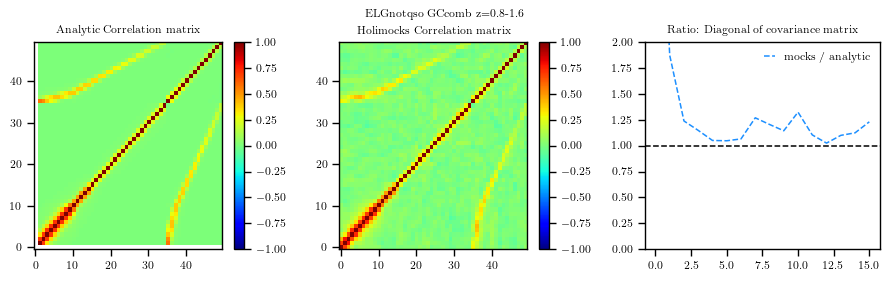

/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/lsstypes/base.py:3152: RuntimeWarning: invalid value encountered in divide
  corrcoef = self._value / (std[..., None] * std)


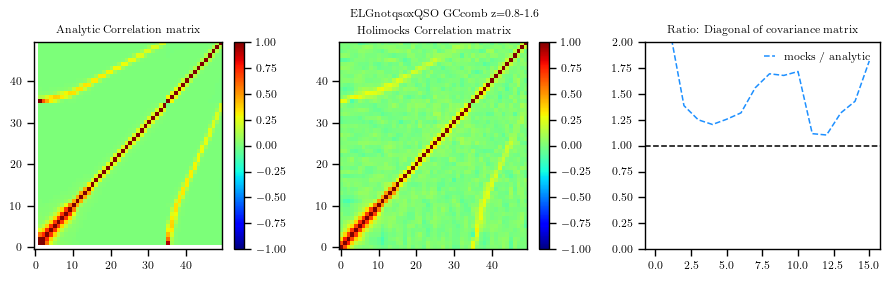

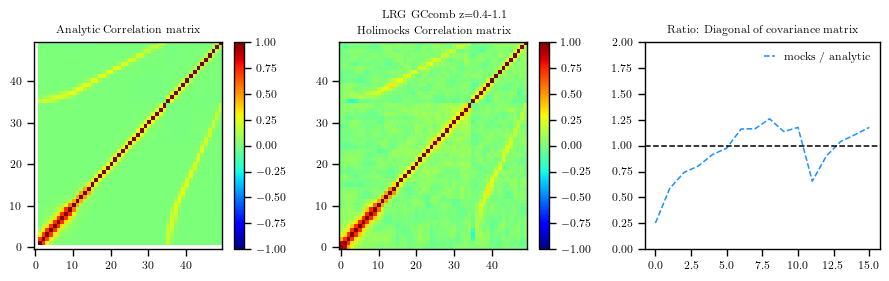

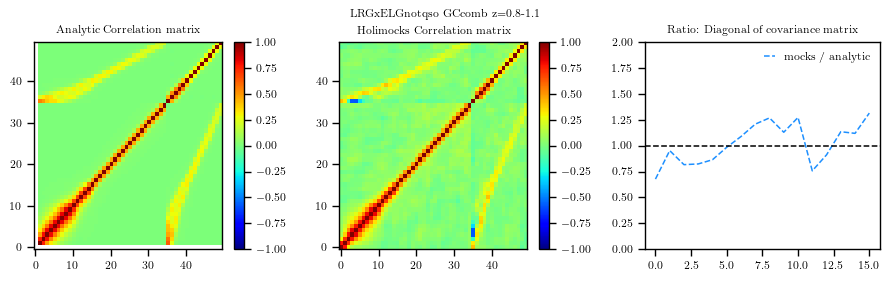

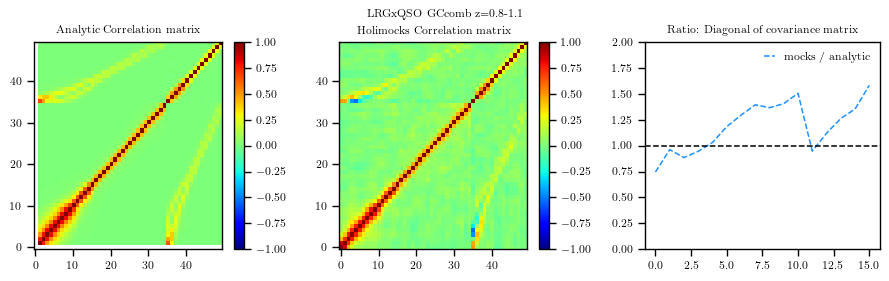

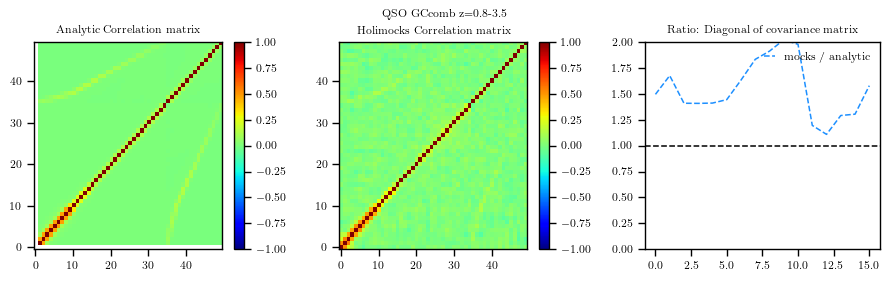

Figure sauvegardée: /Users/edmond/Work/desi-clustering/local_png/fig/check_mocks_covariances.pdf


In [ ]:
pdf_path = Path('fig/check_mocks_covariances.pdf')

with PdfPages(pdf_path) as pdf:
    for tracer in tracers_available:

        tracers = tuple(tracer.split('x'))
        if len(tracers) == 1: tracers *= 2
        tracers = (tracers[0][:3], tracers[1][:3])  # LRG_zcmb -> LRG, ELGnotqso -> ELG, ...
    
        region = 'GCcomb'
        zrange = zranges_by_tracer.get(tracer, [])

        try:
            pk_data, _, cov_data, mm = read_data(data_dir=data_dir, tracer=tracer, zrange=zrange.split('-'), weight_type='default-fkp-oqe', region=region)
            pk_data, _, cov_data, _ = rebin_data(pk_data, None, cov_data, mm, tracer=tracer, kmin=1e-4, kmax=0.1)

            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe')
            fns = list(available[sel]['path'])

            pks = [rebin_data(lsstypes.read(fn), None, None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns]
            cov = lsstypes.cov(pks)
            
            fig = plt.figure(figsize=(9, 3))
            plt.subplot(131)
            plt.imshow(cov_data.at.observable.get(tracers=tracers).corrcoef(), origin='lower', aspect='auto', vmin=-1, vmax=1)
            plt.colorbar()
            plt.title('Analytic Correlation matrix')
            plt.subplot(132)
            plt.imshow(cov.corrcoef(), origin='lower', aspect='auto', vmin=-1, vmax=1)
            plt.colorbar()
            plt.title('Holimocks Correlation matrix')
            plt.subplot(133)
            for k in [0]:
                cov_mocks = cov.at.observable.select(k=slice(0, None, 3)).value()
                cov_ana = cov_data.at.observable.select(k=slice(0, None, 3)).at.observable.get(tracers=tracers).value()
                plt.plot(np.diag(cov_mocks, k=k) / np.diag(cov_ana, k=k), ls='--', label='mocks / analytic' if k == 0 else None)
            plt.axhline(1, ls='--', c='k')
            plt.ylim([0, 2])
            plt.legend(loc='upper right')
            plt.title('Ratio: Diagonal of covariance matrix')

            plt.suptitle(f'{tracer} {region} z={zrange}',fontsize=8, y=0.92)    
            plt.tight_layout()
            pdf.savefig(fig)
            plt.show()

        except Exception as e:
            print(f"Erreur pour {tracer}: {e}")

    print(f"Figure sauvegardée: {pdf_path.resolve()}")

## Mocks covariance with / without RIC+AIC:

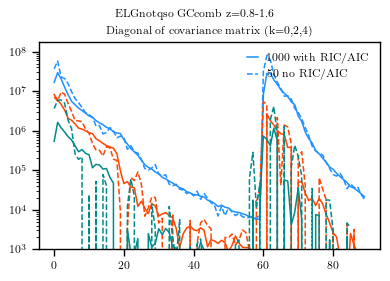

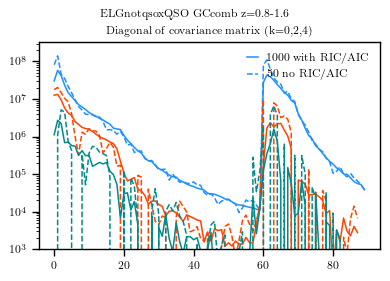

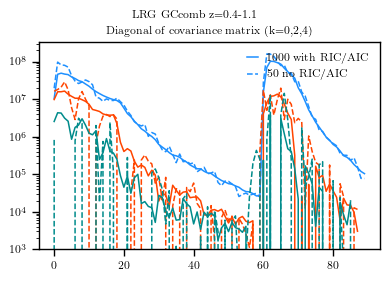

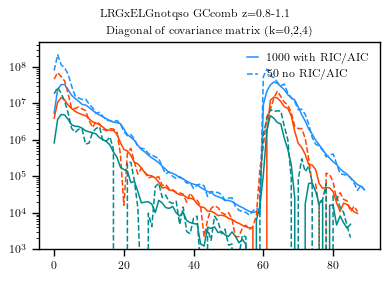

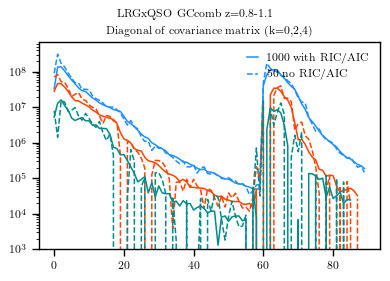

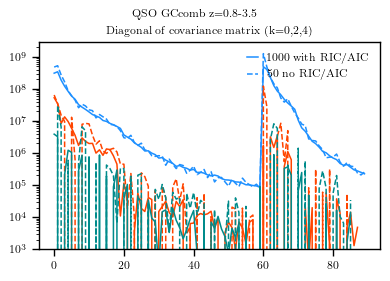

Figure sauvegardée: /Users/edmond/Work/desi-clustering/local_png/fig/check_mocks_covariances_ric_no_ric.pdf


In [ ]:

pdf_path = Path('fig/check_mocks_covariances_ric_no_ric.pdf')

with PdfPages(pdf_path) as pdf:
    for tracer in tracers_available:
    
        region = 'GCcomb'
        zrange = zranges_by_tracer.get(tracer, [])

        try:
            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe')
            fns = list(available[sel]['path'])

            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-noimsys-fkp-oqe')
            fns_noimsys = list(available[sel]['path'])

            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe_reshuffle')
            fns_reshuffle = list(available[sel]['path'])

            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-noimsys-fkp-oqe_reshuffle')
            fns_noimsys_reshuffle = list(available[sel]['path'])

            pks = [rebin_data(lsstypes.read(fn), None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns]
            cov = lsstypes.cov(pks)

            pks = [rebin_data(lsstypes.read(fn), None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns_noimsys_reshuffle]
            cov_noric_noaic = lsstypes.cov(pks)
            
            fig = plt.figure(figsize=(4, 3))
            for k in [0, 2, 4]:
                line, = plt.plot(np.diag(cov.value(), k=k), label='1000 with RIC/AIC' if k == 0 else None)
                plt.plot(np.diag(cov_noric_noaic.value(), k=k), c=line.get_color(), ls='--', label='50 no RIC/AIC' if k == 0 else None)
            plt.yscale('log')
            plt.ylim([1e3, None])
            plt.legend(loc='upper right')
            plt.title('Diagonal of covariance matrix (k=0,2,4)')

            plt.suptitle(f'{tracer} {region} z={zrange}',fontsize=8, y=0.92)    
            plt.tight_layout()
            pdf.savefig(fig)
            plt.show()

        except Exception as e:
            print(f"Erreur pour {tracer}: {e}")

    print(f"Figure sauvegardée: {pdf_path.resolve()}")

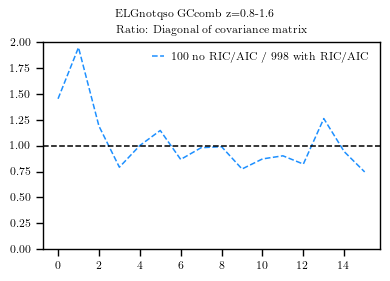

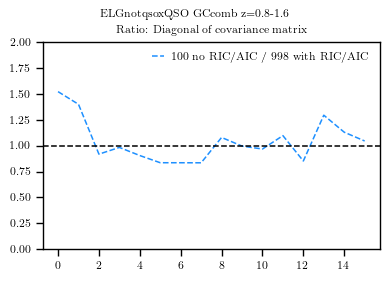

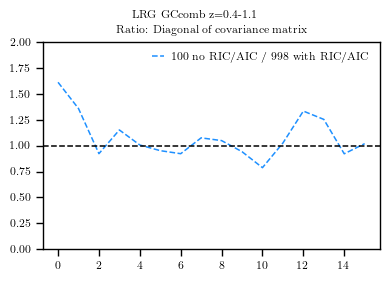

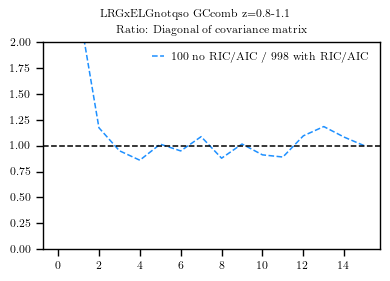

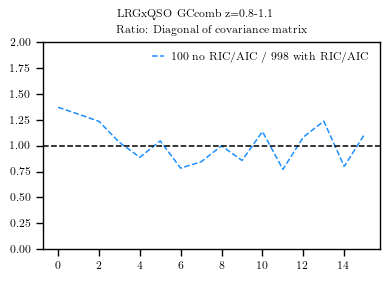

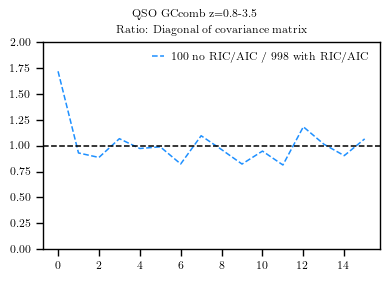

Figure sauvegardée: /Users/edmond/Work/desi-clustering/local_png/fig/check_mocks_covariances_ric_no_ric_ratio.pdf


In [11]:
pdf_path = Path('fig/check_mocks_covariances_ric_no_ric_ratio.pdf')

with PdfPages(pdf_path) as pdf:
    for tracer in tracers_available:
    
        region = 'GCcomb'
        zrange = zranges_by_tracer.get(tracer, [])

        try:
            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe')
            fns = list(available[sel]['path'])

            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-noimsys-fkp-oqe')
            fns_noimsys = list(available[sel]['path'])

            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-fkp-oqe_reshuffle')
            fns_reshuffle = list(available[sel]['path'])

            sel = (available['tracer'] == tracer) & (available['region'] == region) & (available['zrange'] == zrange) & (available['weight'] == 'default-noimsys-fkp-oqe_reshuffle')
            fns_noimsys_reshuffle = list(available[sel]['path'])

            pks = [rebin_data(lsstypes.read(fn), None, None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns]
            cov = lsstypes.cov(pks)

            pks = [rebin_data(lsstypes.read(fn), None, None, None, kmin=1e-4, kmax=0.1)[0] for fn in fns_noimsys_reshuffle]
            cov_noric_noaic = lsstypes.cov(pks)
            
            fig = plt.figure(figsize=(4, 3))
            for k in [0]:
                cov_mocks_ric_aic = cov.at.observable.select(k=slice(0, None, 3))
                cov_mocks_no_ric_aic = cov_noric_noaic.at.observable.select(k=slice(0, None, 3))
                plt.plot(np.diag(cov_mocks_no_ric_aic.value(), k=k) / np.diag(cov_mocks_ric_aic.value(), k=k), ls='--', label='100 no RIC/AIC / 998 with RIC/AIC' if k == 0 else None)
            plt.axhline(1, ls='--', c='k')
            plt.ylim([0, 2])
            plt.legend(loc='upper right')
            plt.title('Ratio: Diagonal of covariance matrix')

            plt.suptitle(f'{tracer} {region} z={zrange}',fontsize=8, y=0.92)    
            plt.tight_layout()
            pdf.savefig(fig)
            plt.show()

        except Exception as e:
            print(f"Erreur pour {tracer}: {e}")

    print(f"Figure sauvegardée: {pdf_path.resolve()}")


In [67]:
kk = [branch.k for branch in cov_mocks_ric_aic.observable._branches]
print(kk)

[array([0.002241  , 0.00480914, 0.00769536, 0.01064657, 0.01361241,
       0.01658752, 0.02012779, 0.0252372 , 0.03119485, 0.03716267,
       0.04314031, 0.04912187, 0.05510815, 0.06109893, 0.06708968,
       0.07308318, 0.07907737, 0.0850709 , 0.09106579, 0.09706114]), array([0.00448951, 0.00964256, 0.01539352, 0.02371227, 0.03469858,
       0.04651689, 0.05841139, 0.07034335, 0.08229294, 0.09425414])]
